# Why $|\Psi_x| \neq |\Psi_y|$ in a slab box

In a $1000 \times 1000 \times 200\;h^{-1}\mathrm{Mpc}$ slab, the $|\Psi_x|$ and $|\Psi_y|$ histograms remain visibly different after averaging 500 random fields. The difference can look clearer as more fields are averaged.

The calculations below show that this difference comes from cosmic variance. A few long-wavelength Fourier modes dominate displacement variance and project onto individual axes. The x-to-y ratio is therefore close to the ratio of two independent $\chi^2(2)$ variables, which follows an $F(2,2)$ distribution with infinite variance and converges slowly.

The notebook covers:

1. The slab grid and its Fourier modes
2. Per-mode contributions to the displacement variance
3. The contribution from fundamental modes
4. Per-realisation variance ratios
5. Why the difference becomes easier to see
6. Paired-fixed amplitudes

In [2]:
from __future__ import annotations

import numpy as np
from numpy.fft import fftfreq, rfftfreq, rfftn, irfftn
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Okabe-Ito colourblind-safe palette
OI = ['#000000', '#E69F00', '#56B4E9', '#009E73',
      '#F0E442', '#0072B2', '#D55E00', '#CC79A7']

plt.rcParams.update({
    'figure.dpi': 140,
    'axes.prop_cycle': plt.cycler(color=OI),
    'font.size': 10,
})

## 1. Grid Setup

This is the grid built by `stepsic.field.cubic_voxels` for the slab-sampling campaign:

$$
L_x = L_y = 1000\;h^{-1}\mathrm{Mpc},\qquad
L_z = 200\;h^{-1}\mathrm{Mpc},\qquad
N_\mathrm{mesh} = 64.
$$

Cubic voxels use $\Delta x = L_\mathrm{min}/N_\mathrm{min}$, giving $N_x = N_y = 320$, $N_z = 64$, and $\Delta x = 3.125\;h^{-1}\mathrm{Mpc}$.

In [3]:
# --- Slab box parameters (matching the validation run) ---
boxsize = np.array([1000.0, 1000.0, 200.0])  # Mpc/h
nmesh = 64

# cubic_voxels logic
nvox = np.ceil(boxsize / (np.min(boxsize) / nmesh)).astype(int)
nvox = (nvox + nvox % 2).astype(int)     # enforce even
dk = np.min(boxsize) / np.min(nvox)       # cell size
N = int(np.prod(nvox))                    # total grid points

print(f"nvox         = {nvox}")
print(f"dk           = {dk} Mpc/h")
print(f"nvox * dk    = {nvox * dk}  (== boxsize ✓)")
print(f"N_particles  = {N:,}")

# Fourier grid (rFFT convention: Hermitian along z)
kx = fftfreq(nvox[0]) * 2 * np.pi / dk
ky = fftfreq(nvox[1]) * 2 * np.pi / dk
kz = rfftfreq(nvox[2]) * 2 * np.pi / dk
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
kmod = np.sqrt(KX**2 + KY**2 + KZ**2)
mask = kmod > 0

k_f = 2 * np.pi / boxsize  # fundamental modes per axis
print(f"\nFundamental modes:  k_f,x = k_f,y = {k_f[0]:.5f},  k_f,z = {k_f[2]:.5f} h/Mpc")
print(f"Ratio k_f,z / k_f,x = {k_f[2]/k_f[0]:.0f}  (z fundamental 5× coarser)")

nvox         = [320 320  64]
dk           = 3.125 Mpc/h
nvox * dk    = [1000. 1000. 200.]  (== boxsize ✓)
N_particles  = 6,553,600

Fundamental modes:  k_f,x = k_f,y = 0.00628,  k_f,z = 0.03142 h/Mpc
Ratio k_f,z / k_f,x = 5  (z fundamental 5× coarser)


## 2. Per-Mode Contributions to the Displacement Variance

The displacement field $\Psi_i(\mathbf{q})$ at Lagrangian position
$\mathbf{q}$ is computed from the Fourier-space overdensity
$\delta(\mathbf{k})$ via

$$
\hat\Psi_i(\mathbf{k}) = \frac{i\,k_i}{|\mathbf{k}|^2}\,\delta(\mathbf{k}).
$$

The **variance of $\Psi_x$ across all grid points** follows from
Parseval's theorem:

$$
\operatorname{Var}(\Psi_x)
  = \frac{1}{N}\sum_{\mathbf{k}\neq 0}
    \frac{k_x^2}{|\mathbf{k}|^4}\,\frac{P(|\mathbf{k}|)}{\Delta x^3},
$$

where $P(k)$ is the matter power spectrum and $\Delta x^3$ is the
Fourier-cell volume. The contribution of each mode is
$\propto k_x^2 / |\mathbf{k}|^4 \, P(|\mathbf{k}|)$, which is
**largest for the smallest $|\mathbf{k}|$** (because $P(k)$ is red and
$1/k^4$ is steep).

We use a simple power-law $P(k) \propto k^{-2.5}$ for illustration;
the qualitative result is independent of the spectral shape.

Deterministic (ensemble) variance contributions:
  Σ w_x = 2.299492e+10   (Ψ_x)
  Σ w_y = 2.299492e+10   (Ψ_y)
  Σ w_z = 2.801739e+08   (Ψ_z)
  Σ w_x / Σ w_y = 0.999999999999999  ← exact unity


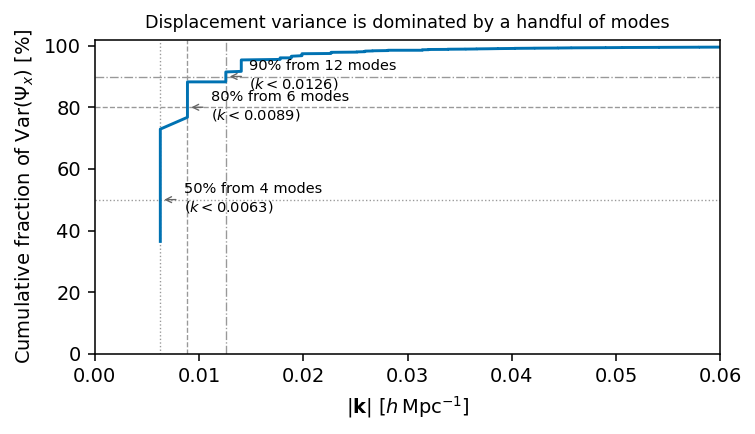

In [4]:
# Smooth power-law P(k) for illustration
pk_grid = np.zeros_like(kmod)
pk_grid[mask] = 1e4 * (kmod[mask] / 0.1)**(-2.5)

# Per-mode contribution to displacement variance along each axis
#   w_i(k) = k_i^2 / |k|^4 * P(|k|) / dk^3
w_x = np.zeros_like(kmod)
w_y = np.zeros_like(kmod)
w_z = np.zeros_like(kmod)
w_x[mask] = KX[mask]**2 / kmod[mask]**4 * pk_grid[mask] / dk**3
w_y[mask] = KY[mask]**2 / kmod[mask]**4 * pk_grid[mask] / dk**3
w_z[mask] = KZ[mask]**2 / kmod[mask]**4 * pk_grid[mask] / dk**3

total_x = np.sum(w_x)  # ∝ Var(Ψ_x)
total_y = np.sum(w_y)
total_z = np.sum(w_z)

print(f"Deterministic (ensemble) variance contributions:")
print(f"  Σ w_x = {total_x:.6e}   (Ψ_x)")
print(f"  Σ w_y = {total_y:.6e}   (Ψ_y)")
print(f"  Σ w_z = {total_z:.6e}   (Ψ_z)")
print(f"  Σ w_x / Σ w_y = {total_x / total_y:.15f}  ← exact unity")

# Sort all modes by |k| and compute the cumulative fraction
k_flat = kmod[mask].ravel()
wx_flat = w_x[mask].ravel()
order = np.argsort(k_flat)
k_sorted = k_flat[order]
cum_x = np.cumsum(wx_flat[order]) / total_x

# --- Figure 1: cumulative variance vs k ---
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(k_sorted, cum_x * 100, color=OI[5], lw=1.5)
for frac, ls in [(50, ':'), (80, '--'), (90, '-.')]:
    idx = np.searchsorted(cum_x, frac / 100)
    k_val = k_sorted[idx]
    n_modes = idx + 1
    ax.axhline(frac, color='0.6', ls=ls, lw=0.7, zorder=0)
    ax.axvline(k_val, color='0.6', ls=ls, lw=0.7, zorder=0)
    ax.annotate(
        f'{frac}% from {n_modes} modes\n($k < {k_val:.4f}$)',
        xy=(k_val, frac), fontsize=7.5,
        xytext=(12, -6), textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='0.4', lw=0.7),
    )

ax.set_xlabel(r'$|\mathbf{k}|$ [$h\,\mathrm{Mpc}^{-1}$]')
ax.set_ylabel(r'Cumulative fraction of $\mathrm{Var}(\Psi_x)$ [%]')
ax.set_xlim(0, 0.06)
ax.set_ylim(0, 102)
ax.set_title('Displacement variance is dominated by a handful of modes', fontsize=9)
fig.tight_layout()
plt.show()

## 3. Contribution from the fundamental modes

The table lists the 12 modes that contribute most to displacement variance.

The two fundamental modes along $x$ and $y$ -
$\mathbf{n} = (\pm 1, 0, 0)$ and $(0, \pm 1, 0)$ - each carry
36.5% of $\operatorname{Var}(\Psi)$. Each mode contributes to only one of the two components:

| Mode | Contributes to | Contributes to |
|------|:-:|:-:|
| $(\pm 1,\,0,\,0)$ | $\Psi_x$ only ✓ | $\Psi_y$ ✗ |
| $(0,\,\pm 1,\,0)$ | $\Psi_x$ ✗ | $\Psi_y$ only ✓ |

The two amplitudes are independent. For a Gaussian field, $|\delta(\mathbf{k})|^2$ follows an exponential distribution. Their ratio is

$$
R = \frac{|\delta(1,0,0)|^2}{|\delta(0,1,0)|^2}
$$

This is an $F(2,2)$ distribution with infinite variance and a probability density that decays as $R^{-2}$. Individual fields can therefore have $\mathrm{Var}(\Psi_x) / \mathrm{Var}(\Psi_y)$ ratios from 0.1 to 10.

In [5]:
# List the modes with the largest variance contributions.
w_tot = w_x + w_y + w_z
total = np.sum(w_tot)

idx_flat = np.argsort(w_tot.ravel())[::-1]
nvox_k = (nvox[0], nvox[1], nvox[2] // 2 + 1)
idx_3d = np.unravel_index(idx_flat[:12], nvox_k)

print(f"{'#':>3s}  {'(nx, ny, nz)':>14s}  {'|k|':>8s}  {'k/k_f':>6s}  "
      f"{'Ψ_x frac':>9s}  {'Ψ_y frac':>9s}  {'Ψ_z frac':>9s}")
print("-" * 78)
for rank in range(12):
    ix, iy, iz = idx_3d[0][rank], idx_3d[1][rank], idx_3d[2][rank]
    k_val = kmod[ix, iy, iz]
    fx = w_x[ix, iy, iz] / total * 100
    fy = w_y[ix, iy, iz] / total * 100
    fz = w_z[ix, iy, iz] / total * 100
    nx = ix if ix <= nvox[0] // 2 else ix - nvox[0]
    ny = iy if iy <= nvox[1] // 2 else iy - nvox[1]
    print(f"{rank+1:3d}  ({nx:+4d},{ny:+4d},{iz:+3d})  {k_val:8.5f}  "
          f"{k_val/k_f[0]:6.2f}  {fx:8.2f}%  {fy:8.2f}%  {fz:8.2f}%")

frac_fund = (w_x[1,0,0] + w_y[0,1,0]) / total * 100
print(f"\n→ Modes (±1,0,0) + (0,±1,0) together carry "
      f"{frac_fund:.0f}% of the total displacement variance.")
print("  Their amplitudes are independent random draws.")

  #    (nx, ny, nz)       |k|   k/k_f   Ψ_x frac   Ψ_y frac   Ψ_z frac
------------------------------------------------------------------------------
  1  (  +0,  +1, +0)   0.00628    1.00      0.00%     18.13%      0.00%
  2  (  -1,  +0, +0)   0.00628    1.00     18.13%      0.00%      0.00%
  3  (  +0,  -1, +0)   0.00628    1.00      0.00%     18.13%      0.00%
  4  (  +1,  +0, +0)   0.00628    1.00     18.13%      0.00%      0.00%
  5  (  +1,  +1, +0)   0.00889    1.41      1.91%      1.91%      0.00%
  6  (  -1,  +1, +0)   0.00889    1.41      1.91%      1.91%      0.00%
  7  (  -1,  -1, +0)   0.00889    1.41      1.91%      1.91%      0.00%
  8  (  +1,  -1, +0)   0.00889    1.41      1.91%      1.91%      0.00%
  9  (  +2,  +0, +0)   0.01257    2.00      0.80%      0.00%      0.00%
 10  (  +0,  +2, +0)   0.01257    2.00      0.00%      0.80%      0.00%
 11  (  +0,  -2, +0)   0.01257    2.00      0.00%      0.80%      0.00%
 12  (  -2,  +0, +0)   0.01257    2.00      0.80%      0.0

## 4. Per-Realisation Variance Ratios

We generate many independent realisations (independent white-noise
seeds), compute the displacement variance along $x$ and $y$ for each,
and plot the distribution of the ratio
$\mathrm{Var}(\Psi_x) / \mathrm{Var}(\Psi_y)$.

Because the two fundamental-mode amplitudes dominate this ratio, it is approximately $F(2,2)$ distributed and has a slowly decaying tail.

> Sections 4–7 each run about 100 FFTs on a $320 \times 320 \times 64$ grid. They take about five minutes in total on a modern laptop.

Done: 200 realisations in 66 s


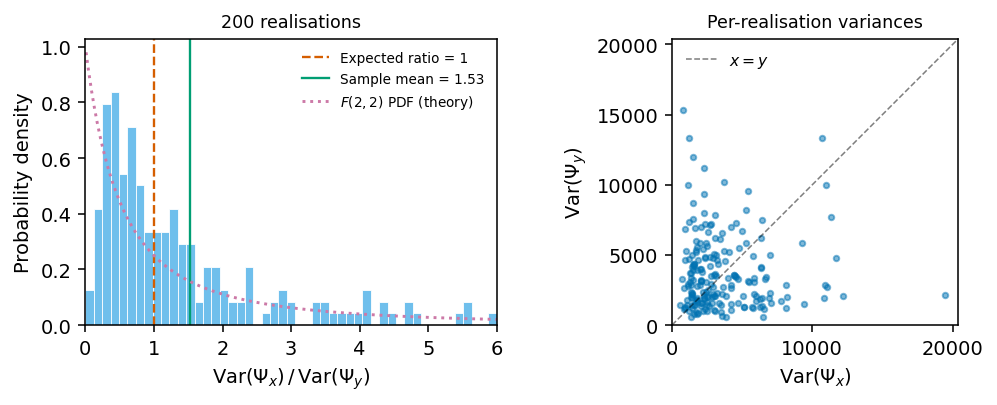

Var(Ψ_x)/Var(Ψ_y) per realisation:
  mean  = 1.5284
  std   = 1.6499
  range = [0.051, 11.276]

Compare with F(2,2): E[R] = ∞ (undefined), median = 1.0
  Our sample median = 0.9517


In [6]:
import time

target_A = np.sqrt(pk_grid / dk**3)
fft_axes = (0, 1, 2)

n_real = 200
base_seed = 42

var_x_arr = np.empty(n_real)
var_y_arr = np.empty(n_real)
var_z_arr = np.empty(n_real)

t0 = time.time()
for i in range(n_real):
    rng = np.random.default_rng(base_seed + i)
    noise = rng.standard_normal(size=tuple(nvox))
    w_k = rfftn(noise, axes=fft_axes)
    w_k[0, 0, 0] = 0.0
    delta_k = w_k * target_A

    phi_k = np.zeros_like(kmod, dtype=complex)
    phi_k[mask] = -delta_k[mask] / kmod[mask]**2

    psi_x = irfftn(-1j * phi_k * KX, s=tuple(nvox), axes=fft_axes)
    psi_y = irfftn(-1j * phi_k * KY, s=tuple(nvox), axes=fft_axes)
    psi_z = irfftn(-1j * phi_k * KZ, s=tuple(nvox), axes=fft_axes)

    var_x_arr[i] = np.var(psi_x)
    var_y_arr[i] = np.var(psi_y)
    var_z_arr[i] = np.var(psi_z)

print(f"Done: {n_real} realisations in {time.time()-t0:.0f} s")

ratio_xy = var_x_arr / var_y_arr

# --- Figure 2: histogram of per-realisation ratios ---
fig, axes_fig = plt.subplots(1, 2, figsize=(7.5, 3.0))

# Left: histogram of Var(Ψ_x)/Var(Ψ_y)
ax = axes_fig[0]
bins_r = np.linspace(0, 6, 50)
ax.hist(ratio_xy, bins=bins_r, color=OI[2], edgecolor='white',
        lw=0.5, alpha=0.85, density=True)
ax.axvline(1.0, color=OI[6], ls='--', lw=1.2, label='Expected ratio = 1')
ax.axvline(np.mean(ratio_xy), color=OI[3], ls='-', lw=1.2,
           label=f'Sample mean = {np.mean(ratio_xy):.2f}')

# Overlay the F(2,2) PDF for comparison
from scipy.stats import f as f_dist
r_grid = np.linspace(0.01, 6, 300)
ax.plot(r_grid, f_dist.pdf(r_grid, 2, 2), color=OI[7], lw=1.5,
        ls=':', label=r'$F(2,2)$ PDF (theory)')

ax.set_xlabel(r'$\mathrm{Var}(\Psi_x)\,/\,\mathrm{Var}(\Psi_y)$')
ax.set_ylabel('Probability density')
ax.set_xlim(0, 6)
ax.legend(fontsize=7, frameon=False)
ax.set_title(f'{n_real} realisations', fontsize=9)

# Right: scatter of Var(Ψ_x) vs Var(Ψ_y)
ax = axes_fig[1]
ax.scatter(var_x_arr, var_y_arr, s=8, alpha=0.5, color=OI[5], zorder=2)
lim = max(var_x_arr.max(), var_y_arr.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5, label='$x = y$')
ax.set_xlabel(r'$\mathrm{Var}(\Psi_x)$')
ax.set_ylabel(r'$\mathrm{Var}(\Psi_y)$')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect('equal')
ax.legend(fontsize=8, frameon=False)
ax.set_title('Per-realisation variances', fontsize=9)

fig.tight_layout()
plt.show()

print(f"Var(Ψ_x)/Var(Ψ_y) per realisation:")
print(f"  mean  = {np.mean(ratio_xy):.4f}")
print(f"  std   = {np.std(ratio_xy):.4f}")
print(f"  range = [{np.min(ratio_xy):.3f}, {np.max(ratio_xy):.3f}]")
print(f"\nCompare with F(2,2): E[R] = ∞ (undefined), median = 1.0")
print(f"  Our sample median = {np.median(ratio_xy):.4f}")

## 5. Why the difference becomes easier to see

Averaging over $N_\mathrm{real}$ random fields has two effects:

1. Bin-to-bin noise drops as $1/\sqrt{N_\mathrm{real}}$, so the curves become smoother.
2. The shape difference between $|\Psi_x|$ and $|\Psi_y|$ also decreases, but more slowly because fewer than ten independent modes dominate it, not all $6.5 \times 10^6$ grid values.

The noise drops faster than the difference, making the difference easier to see even while it shrinks. Roughly $10^4$ random fields are needed to reduce it below the remaining noise.

In [ ]:
import time

# Accumulate histograms and snapshot at several N_real values
n_real_max = 200   # ~2 min on a modern laptop
nbins = 80

# Get bin range from a pilot run
rng_pilot = np.random.default_rng(base_seed)
noise_pilot = rng_pilot.standard_normal(size=tuple(nvox))
w_pilot = rfftn(noise_pilot, axes=fft_axes); w_pilot[0,0,0] = 0.0
dk_pilot = w_pilot * target_A
phi_pilot = np.zeros_like(kmod, dtype=complex)
phi_pilot[mask] = -dk_pilot[mask] / kmod[mask]**2
pilot_x = irfftn(-1j * phi_pilot * KX, s=tuple(nvox), axes=fft_axes)
bin_max = np.max(np.abs(pilot_x)) * 1.8
bin_edges = np.linspace(0, bin_max, nbins + 1)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

accum_x = np.zeros(nbins, dtype=np.float64)
accum_y = np.zeros(nbins, dtype=np.float64)

snapshots = [5, 20, 50, 200]
snapshot_data = {}

t0 = time.time()
for i in range(1, n_real_max + 1):
    rng = np.random.default_rng(base_seed + i - 1)
    noise = rng.standard_normal(size=tuple(nvox))
    w_k = rfftn(noise, axes=fft_axes); w_k[0,0,0] = 0.0
    delta_k = w_k * target_A
    phi_k = np.zeros_like(kmod, dtype=complex)
    phi_k[mask] = -delta_k[mask] / kmod[mask]**2

    psi_x = irfftn(-1j * phi_k * KX, s=tuple(nvox), axes=fft_axes)
    psi_y = irfftn(-1j * phi_k * KY, s=tuple(nvox), axes=fft_axes)

    hx, _ = np.histogram(np.abs(psi_x.ravel()), bins=bin_edges)
    hy, _ = np.histogram(np.abs(psi_y.ravel()), bins=bin_edges)
    accum_x += hx.astype(np.float64)
    accum_y += hy.astype(np.float64)

    if i in snapshots:
        snapshot_data[i] = (accum_x.copy() / i, accum_y.copy() / i)

print(f"Done: {n_real_max} realisations in {time.time()-t0:.0f} s")

# --- Figure 3: accumulated histograms at different N_real ---
fig, axes_fig = plt.subplots(2, 2, figsize=(7.5, 5.5))

for ax, n_snap in zip(axes_fig.ravel(), snapshots):
    hx_avg, hy_avg = snapshot_data[n_snap]

    # Step-style histogram, clipping zero bins for log-y
    for counts, color, label in [
        (hx_avg, OI[6], r'$|\Psi_x|$'),
        (hy_avg, OI[5], r'$|\Psi_y|$'),
    ]:
        pos = counts > 0
        if np.any(pos):
            idx = np.flatnonzero(pos)
            i0, i1 = idx[0], idx[-1] + 1
            ax.stairs(counts[i0:i1], bin_edges[i0:i1+1],
                      color=color, lw=1.2, label=label)

    ax.set_yscale('log')
    ax.set_title(f'$N_\\mathrm{{real}} = {n_snap}$', fontsize=9)
    ax.legend(fontsize=7, loc='upper right', frameon=False)
    ax.set_xlim(0, bin_max * 0.85)

for ax in axes_fig[1]:
    ax.set_xlabel(r'$|\Psi_i|$  [Mpc/$h$]')
for ax in axes_fig[:, 0]:
    ax.set_ylabel(r'Mean counts $\langle N \rangle$')

fig.suptitle(
    r'Accumulated $|\Psi_x|$ vs $|\Psi_y|$ histograms - '
    'the gap sharpens as noise drops',
    fontsize=10, y=1.01,
)
fig.tight_layout()
plt.show()

## 6. Fixed amplitudes remove the difference

The Angulo & Pontzen (2016) paired-fixed method replaces each mode's random Rayleigh-distributed amplitude with the fixed target $\sqrt{P(k)}$ and retains its random phase.

Because $N_x = N_y$ and the Fourier grid is symmetric, the fixed sum $\sum_\mathbf{k} k_x^2 / |\mathbf{k}|^4 \, P(|\mathbf{k}|)$ is unchanged when x and y are exchanged. Fixed amplitudes therefore give $\mathrm{Var}(\Psi_x) = \mathrm{Var}(\Psi_y)$ to machine precision for every random phase field.

The exact agreement with fixed amplitudes shows that the difference comes from the random amplitudes rather than from an x-to-y difference in the implementation.

In [ ]:
# Compare random vs fixed amplitudes
n_test = 30

results = {}
for label, use_fixed in [('Random amplitudes', False),
                          ('Fixed amplitudes', True)]:
    ratios = []
    for seed in range(137, 137 + n_test):
        rng = np.random.default_rng(seed)
        noise = rng.standard_normal(size=tuple(nvox))
        w_k = rfftn(noise, axes=fft_axes)
        w_k[0, 0, 0] = 0.0

        if use_fixed:
            # Angulo & Pontzen: set |δ_k| = √(N) * target_A, keep phase
            amp = np.abs(w_k)
            phase = np.zeros_like(w_k)
            pos = amp > 0
            phase[pos] = w_k[pos] / amp[pos]
            delta_k = phase * (np.sqrt(np.prod(nvox)) * target_A)
        else:
            delta_k = w_k * target_A

        phi_k = np.zeros_like(kmod, dtype=complex)
        phi_k[mask] = -delta_k[mask] / kmod[mask]**2

        psi_x = irfftn(-1j * phi_k * KX, s=tuple(nvox), axes=fft_axes)
        psi_y = irfftn(-1j * phi_k * KY, s=tuple(nvox), axes=fft_axes)
        ratios.append(np.var(psi_x) / np.var(psi_y))

    ratios = np.array(ratios)
    results[label] = ratios
    print(f"{label}:")
    print(f"  Var(Ψ_x)/Var(Ψ_y):  mean = {np.mean(ratios):.10f}  "
          f"std = {np.std(ratios):.2e}  "
          f"range = [{np.min(ratios):.6f}, {np.max(ratios):.6f}]")

# --- Figure 4: side-by-side comparison ---
fig, axes_fig = plt.subplots(1, 2, figsize=(7.5, 3.0))

ax = axes_fig[0]
ax.hist(results['Random amplitudes'], bins=20, color=OI[6],
        edgecolor='white', lw=0.5, alpha=0.85)
ax.axvline(1.0, color='k', ls='--', lw=1)
ax.set_xlabel(r'$\mathrm{Var}(\Psi_x)\,/\,\mathrm{Var}(\Psi_y)$')
ax.set_ylabel('Count')
ax.set_title('Random amplitudes', fontsize=9)

ax = axes_fig[1]
ax.hist(results['Fixed amplitudes'], bins=20, color=OI[3],
        edgecolor='white', lw=0.5, alpha=0.85)
ax.axvline(1.0, color='k', ls='--', lw=1)
ax.set_xlabel(r'$\mathrm{Var}(\Psi_x)\,/\,\mathrm{Var}(\Psi_y)$')
ax.set_title('Fixed amplitudes (Angulo & Pontzen 2016)', fontsize=9)
# Set symmetric xlim matching left panel
xlim = axes_fig[0].get_xlim()
axes_fig[1].set_xlim(max(0, 1 - 0.5e-14), 1 + 0.5e-14)

fig.tight_layout()
plt.show()

## 7. The Cubic Box: A Less Extreme Case

In a cubic box ($N_x = N_y = N_z$), the three fundamental modes
$(1,0,0)$, $(0,1,0)$, and $(0,0,1)$ all sit at the same $|\mathbf{k}|$
and contribute equally to $\Psi_x$, $\Psi_y$, $\Psi_z$ respectively.
The variance per mode is the same, but it is now split three ways
instead of being concentrated into a single axis projection.

More importantly, the variance per component is smaller relative to the
total (each axis gets $\sim 1/3$), and the next harmonic modes contribute
a larger relative share, so convergence with $N_\mathrm{real}$ is
somewhat faster - though the same fundamental issue persists.

In [ ]:
# Quick comparison: cubic box
nvox_cube = np.array([64, 64, 64])
dk_cube = 1000.0 / 64  # same Lbox
N_cube = int(np.prod(nvox_cube))

kx_c = fftfreq(64) * 2 * np.pi / dk_cube
ky_c = fftfreq(64) * 2 * np.pi / dk_cube
kz_c = rfftfreq(64) * 2 * np.pi / dk_cube
KXc, KYc, KZc = np.meshgrid(kx_c, ky_c, kz_c, indexing='ij')
kmod_c = np.sqrt(KXc**2 + KYc**2 + KZc**2)
mask_c = kmod_c > 0

pk_c = np.zeros_like(kmod_c)
pk_c[mask_c] = 1e4 * (kmod_c[mask_c] / 0.1)**(-2.5)
target_A_c = np.sqrt(pk_c / dk_cube**3)

n_test = 100
ratio_cube = np.empty(n_test)
ratio_slab = np.empty(n_test)
for i in range(n_test):
    rng = np.random.default_rng(1000 + i)

    # Cube
    w = rfftn(rng.standard_normal(size=tuple(nvox_cube)), axes=fft_axes)
    w[0,0,0] = 0.0
    dk_field = w * target_A_c
    phi = np.zeros_like(kmod_c, dtype=complex)
    phi[mask_c] = -dk_field[mask_c] / kmod_c[mask_c]**2
    px = irfftn(-1j * phi * KXc, s=tuple(nvox_cube), axes=fft_axes)
    py = irfftn(-1j * phi * KYc, s=tuple(nvox_cube), axes=fft_axes)
    ratio_cube[i] = np.var(px) / np.var(py)

    # Slab (reuse global grid)
    rng2 = np.random.default_rng(1000 + i)
    w2 = rfftn(rng2.standard_normal(size=tuple(nvox)), axes=fft_axes)
    w2[0,0,0] = 0.0
    dk_field2 = w2 * target_A
    phi2 = np.zeros_like(kmod, dtype=complex)
    phi2[mask] = -dk_field2[mask] / kmod[mask]**2
    px2 = irfftn(-1j * phi2 * KX, s=tuple(nvox), axes=fft_axes)
    py2 = irfftn(-1j * phi2 * KY, s=tuple(nvox), axes=fft_axes)
    ratio_slab[i] = np.var(px2) / np.var(py2)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
bins_r = np.linspace(0, 5, 40)
ax.hist(ratio_cube, bins=bins_r, alpha=0.6, color=OI[2], edgecolor='white',
        lw=0.5, label=f'Cubic $1000^3$ (std = {np.std(ratio_cube):.2f})', density=True)
ax.hist(ratio_slab, bins=bins_r, alpha=0.5, color=OI[6], edgecolor='white',
        lw=0.5, label=f'Slab $1000^2 \\times 200$ (std = {np.std(ratio_slab):.2f})', density=True)
ax.axvline(1.0, color='k', ls='--', lw=1)
ax.set_xlabel(r'$\mathrm{Var}(\Psi_x)\,/\,\mathrm{Var}(\Psi_y)$')
ax.set_ylabel('Probability density')
ax.legend(fontsize=8, frameon=False)
ax.set_title('The slab has broader cosmic-variance tails', fontsize=9)
fig.tight_layout()
plt.show()

print(f"Cubic box:  std(ratio) = {np.std(ratio_cube):.3f},  "
      f"range = [{np.min(ratio_cube):.2f}, {np.max(ratio_cube):.2f}]")
print(f"Slab box:   std(ratio) = {np.std(ratio_slab):.3f},  "
      f"range = [{np.min(ratio_slab):.2f}, {np.max(ratio_slab):.2f}]")

## 8. Summary

| Observation | Explanation |
|:--|:--|
| $\|\Psi_x\| \neq \|\Psi_y\|$ in one random field | The two fundamental modes $(1,0,0)$ and $(0,1,0)$ carry 73% of the variance and project onto different axes. Their amplitudes are independent $\chi^2(2)$ draws. |
| The difference becomes clearer with $N_\mathrm{real}$ | Noise drops as $1/\sqrt{N}$, while the shape difference falls more slowly because fewer than ten modes dominate it. |
| Fixed amplitudes give exact $x = y$ | The sums $\sum k_x^2/k^4 P(k)$ and $\sum k_y^2/k^4 P(k)$ are equal because $N_x = N_y$. Only the random amplitudes break that equality. |
| The slab varies more than the cube | The slab concentrates 73% of its variance in two modes, so its variance ratio has broader tails. |

The x-to-y difference is expected cosmic variance when roughly one to ten Fourier modes dominate displacement.

### Plotting these distributions

- Total $|\Psi|$ and $|v|$ histograms are stable because they combine all three axes.
- Per-component slab histograms need fixed amplitudes or an explanation that random long-wavelength modes can separate x and y.